# Train the softmax baseline and define alpha cohorts

This notebook builds on `02_cifar100_training_baseline.ipynb`. It fine-tunes the same ImageNet-pretrained **ConvNeXt-Tiny** classifier, keeps ordinary softmax as the baseline activation, and separates CIFAR-100 classes by whether their **calibration-set top-1 accuracy** is below or at/above the target $\alpha = 0.95$.

The official CIFAR-100 test set is deliberately **not loaded or evaluated** here. The class cohorts are development artifacts for the upcoming softmax-versus-SDM experiment, not test results or reliability guarantees.

> Full run: run the notebook normally. Bounded pipeline check: launch Jupyter with `SDM_RUN_MODE=smoke`; smoke outputs cover only a few batches and cannot define meaningful class cohorts.

## Experimental separation

The official 50,000-image CIFAR-100 training set is deterministically divided within every class:

- **45,000 training images** (450/class): gradient updates and deterministic SDM reference export
- **2,500 validation images** (25/class): checkpoint selection only
- **2,500 calibration images** (25/class): class-cohort definition and later activation calibration
- **10,000 official test images**: untouched until the softmax and SDM methods are completely frozen

A class enters the `at_or_above_target` cohort when its observed calibration accuracy is at least 95%; otherwise it enters `below_target`. With only 25 calibration examples per class, accuracy moves in four-percentage-point steps and has substantial sampling uncertainty. The cohort name describes an observed development-set result, not a population-level guarantee.

In [1]:
from __future__ import annotations

import json
import os
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
from torchvision.transforms import InterpolationMode

RUN_MODE = os.environ.get("SDM_RUN_MODE", "benchmark").strip().lower()
if RUN_MODE not in {"benchmark", "smoke"}:
    raise ValueError("SDM_RUN_MODE must be 'benchmark' or 'smoke'.")

SEED = 42
TARGET_ALPHA = 0.95
MODEL_NAME = "convnext_tiny_imagenet1k_v1"
DATA_DIR = Path(os.environ.get(
    "SDM_DATA_DIR", Path.home() / ".cache" / "sdm-vision-reliability"
)).expanduser()
RUN_DIR = Path(os.environ.get(
    "SDM_RUN_DIR",
    Path.home() / ".cache" / "sdm-vision-reliability" / "runs" / MODEL_NAME / f"seed_{SEED}" / RUN_MODE,
)).expanduser()
DATA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

SMOKE = RUN_MODE == "smoke"
IMAGE_SIZE = 224
BATCH_SIZE = 8 if SMOKE else 128
EPOCHS = 1 if SMOKE else 20
MAX_TRAIN_BATCHES = 2 if SMOKE else None
MAX_EXPORT_BATCHES = 2 if SMOKE else None
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
NUM_WORKERS = 0 if platform.system() in {"Windows", "Darwin"} else min(4, os.cpu_count() or 1)
FORCE_RETRAIN = os.environ.get("SDM_FORCE_RETRAIN", "0") == "1"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
USE_AMP = DEVICE.type == "cuda"

CONFIG = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "target_alpha": TARGET_ALPHA,
    "model_name": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "num_workers": NUM_WORKERS,
    "device": str(DEVICE),
    "max_train_batches": MAX_TRAIN_BATCHES,
    "max_export_batches": MAX_EXPORT_BATCHES,
}

print(json.dumps(CONFIG, indent=2))
print(f"Data: {DATA_DIR}")
print(f"Outputs: {RUN_DIR}")
if SMOKE:
    print("SMOKE MODE: partial-batch outputs are pipeline checks, not experiment results.")

{
  "run_mode": "benchmark",
  "seed": 42,
  "target_alpha": 0.95,
  "model_name": "convnext_tiny_imagenet1k_v1",
  "image_size": 224,
  "batch_size": 128,
  "epochs": 20,
  "learning_rate": 0.0003,
  "weight_decay": 0.05,
  "label_smoothing": 0.1,
  "num_workers": 4,
  "device": "cuda",
  "max_train_batches": null,
  "max_export_batches": null
}
Data: /home/randy/.cache/sdm-vision-reliability
Outputs: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark


## Reproducibility controls

In [2]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


seed_everything(SEED)

## Load CIFAR-100 and construct disjoint development splits

Training uses augmentation. Validation, calibration, and the training-reference export use deterministic ImageNet preprocessing. The official test split is not instantiated in this notebook.

In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE, scale=(0.65, 1.0), interpolation=InterpolationMode.BICUBIC
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])

eval_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_aug_base = datasets.CIFAR100(DATA_DIR, train=True, download=True, transform=train_transform)
train_eval_base = datasets.CIFAR100(DATA_DIR, train=True, download=False, transform=eval_transform)

targets = np.asarray(train_aug_base.targets)
rng = np.random.default_rng(SEED)
train_indices, validation_indices, calibration_indices = [], [], []

for class_id in range(100):
    class_indices = rng.permutation(np.flatnonzero(targets == class_id))
    validation_indices.extend(class_indices[:25])
    calibration_indices.extend(class_indices[25:50])
    train_indices.extend(class_indices[50:])

train_indices = np.asarray(train_indices)
validation_indices = np.asarray(validation_indices)
calibration_indices = np.asarray(calibration_indices)

assert len(train_indices) == 45_000
assert len(validation_indices) == 2_500
assert len(calibration_indices) == 2_500
assert not (set(train_indices) & set(validation_indices))
assert not (set(train_indices) & set(calibration_indices))
assert not (set(validation_indices) & set(calibration_indices))

train_dataset = Subset(train_aug_base, train_indices)
reference_dataset = Subset(train_eval_base, train_indices)
validation_dataset = Subset(train_eval_base, validation_indices)
calibration_dataset = Subset(train_eval_base, calibration_indices)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, shuffle=True, generator=train_generator, **loader_options)
reference_loader = DataLoader(reference_dataset, shuffle=False, **loader_options)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)
calibration_loader = DataLoader(calibration_dataset, shuffle=False, **loader_options)

print({
    "training": len(train_dataset),
    "reference (same images, deterministic transform)": len(reference_dataset),
    "validation": len(validation_dataset),
    "calibration": len(calibration_dataset),
    "official test loaded": False,
})

{'training': 45000, 'reference (same images, deterministic transform)': 45000, 'validation': 2500, 'calibration': 2500, 'official test loaded': False}


## Initialize the softmax baseline

ConvNeXt-Tiny starts from torchvision's fixed `IMAGENET1K_V1` weights. The network emits 100 raw logits. `CrossEntropyLoss` applies log-softmax internally during training; explicit softmax is used only when converting logits into baseline probabilities. This separation lets the later experiment replace the probability activation without retraining the feature extractor unless that becomes an explicit experimental condition.

In [4]:
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
model = convnext_tiny(weights=weights)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 100)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f"Parameters: {total_parameters:,}")

Parameters: 27,897,028


## Train and select the checkpoint

Only validation top-1 accuracy selects the checkpoint. The calibration loader is not touched during training. The run directory intentionally matches notebook 02, so an existing complete baseline checkpoint is reused unless `SDM_FORCE_RETRAIN=1` is set.

In [5]:
def classification_epoch(loader, *, training: bool, max_batches: int | None = None) -> dict:
    model.train(training)
    total_loss = 0.0
    total_examples = 0
    top1_correct = 0
    top5_correct = 0

    for batch_number, (inputs, targets_batch) in enumerate(loader):
        if max_batches is not None and batch_number >= max_batches:
            break
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets_batch = targets_batch.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                logits = model(inputs)
                loss = criterion(logits, targets_batch)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        batch_size = targets_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        top5 = logits.topk(5, dim=1).indices
        top1_correct += (top5[:, 0] == targets_batch).sum().item()
        top5_correct += (top5 == targets_batch[:, None]).any(dim=1).sum().item()

    return {
        "loss": total_loss / total_examples,
        "top1_accuracy": top1_correct / total_examples,
        "top5_accuracy": top5_correct / total_examples,
        "examples": total_examples,
    }

In [6]:
checkpoint_path = RUN_DIR / "best_checkpoint.pt"
history = []
best_validation_accuracy = -1.0

checkpoint = None
if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
checkpoint_is_complete = bool(checkpoint and checkpoint.get("training_complete", False))

if checkpoint_is_complete and not FORCE_RETRAIN:
    model.load_state_dict(checkpoint["model_state_dict"])
    history = checkpoint.get("history", [])
    best_validation_accuracy = checkpoint["best_validation_accuracy"]
    print(f"Loaded existing checkpoint: {checkpoint_path}")
else:
    started = time.time()
    for epoch in range(1, EPOCHS + 1):
        train_metrics = classification_epoch(
            train_loader, training=True, max_batches=MAX_TRAIN_BATCHES
        )
        validation_metrics = classification_epoch(
            validation_loader, training=False, max_batches=MAX_EXPORT_BATCHES
        )
        scheduler.step()

        epoch_record = {
            "epoch": epoch,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "train": train_metrics,
            "validation": validation_metrics,
        }
        history.append(epoch_record)
        print(
            f"Epoch {epoch:02d}/{EPOCHS}: "
            f"train top-1={train_metrics['top1_accuracy']:.3%}, "
            f"validation top-1={validation_metrics['top1_accuracy']:.3%}"
        )

        if validation_metrics["top1_accuracy"] > best_validation_accuracy:
            best_validation_accuracy = validation_metrics["top1_accuracy"]
            torch.save({
                "model_state_dict": model.state_dict(),
                "best_validation_accuracy": best_validation_accuracy,
                "history": history,
                "config": CONFIG,
                "class_names": train_aug_base.classes,
                "training_complete": False,
            }, checkpoint_path)

    elapsed_minutes = (time.time() - started) / 60
    print(f"Training completed in {elapsed_minutes:.1f} minutes")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    checkpoint["training_complete"] = True
    checkpoint["completed_epochs"] = EPOCHS
    torch.save(checkpoint, checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])

print(f"Best validation top-1: {best_validation_accuracy:.3%}")

Loaded existing checkpoint: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/best_checkpoint.pt
Best validation top-1: 88.760%


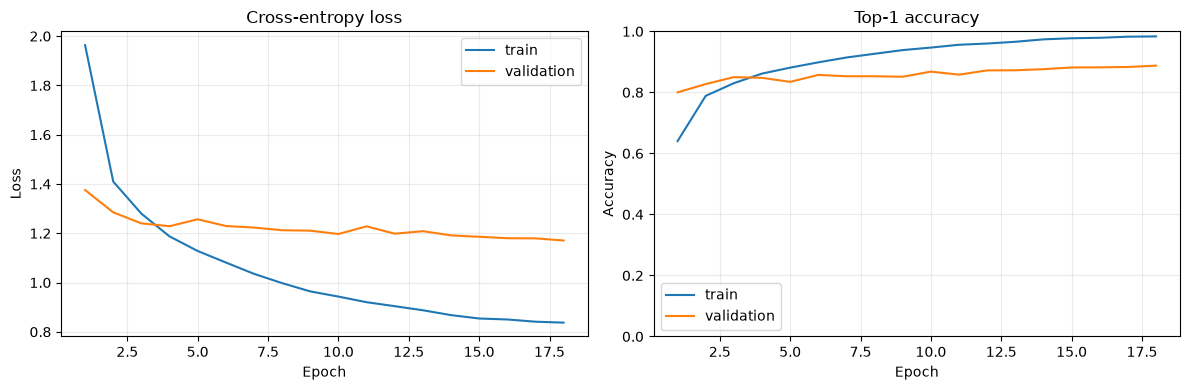

In [7]:
if history:
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, [row["train"]["loss"] for row in history], label="train")
    axes[0].plot(epochs, [row["validation"]["loss"] for row in history], label="validation")
    axes[0].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
    axes[1].plot(epochs, [row["train"]["top1_accuracy"] for row in history], label="train")
    axes[1].plot(epochs, [row["validation"]["top1_accuracy"] for row in history], label="validation")
    axes[1].set(title="Top-1 accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    plt.tight_layout()
    plt.show()

## Export softmax baseline outputs and SDM reference representations

The penultimate embedding is the normalized, pooled ConvNeXt representation immediately before the 100-class linear layer. Training-reference embeddings use deterministic preprocessing. Calibration outputs define the alpha cohorts and can later fit SDM parameters. No held-out test outputs are created here.

In [8]:
@torch.inference_mode()
def collect_outputs(loader, *, max_batches: int | None = None) -> tuple[dict, dict]:
    model.eval()
    all_logits, all_probabilities = [], []
    all_embeddings, all_targets, all_predictions = [], [], []

    for batch_number, (inputs, targets_batch) in enumerate(loader):
        if max_batches is not None and batch_number >= max_batches:
            break
        inputs = inputs.to(DEVICE, non_blocking=True)

        features = model.features(inputs)
        embeddings = model.avgpool(features)
        embeddings = model.classifier[0](embeddings)
        embeddings = model.classifier[1](embeddings)
        logits = model.classifier[2](embeddings)
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        all_logits.append(logits.cpu())
        all_probabilities.append(probabilities.cpu())
        all_embeddings.append(embeddings.cpu())
        all_targets.append(targets_batch.cpu())
        all_predictions.append(predictions.cpu())

    arrays = {
        "logits": torch.cat(all_logits).numpy(),
        "probabilities": torch.cat(all_probabilities).numpy(),
        "embeddings": torch.cat(all_embeddings).numpy(),
        "targets": torch.cat(all_targets).numpy(),
        "predictions": torch.cat(all_predictions).numpy(),
    }
    target_tensor = torch.from_numpy(arrays["targets"])
    logits_tensor = torch.from_numpy(arrays["logits"])
    top5 = logits_tensor.topk(5, dim=1).indices
    metrics = {
        "top1_accuracy": float((torch.from_numpy(arrays["predictions"]) == target_tensor).float().mean()),
        "top5_accuracy": float((top5 == target_tensor[:, None]).any(dim=1).float().mean()),
        "examples": int(len(target_tensor)),
    }
    return arrays, metrics


reference_arrays, reference_metrics = collect_outputs(
    reference_loader, max_batches=MAX_EXPORT_BATCHES
)
calibration_arrays, calibration_metrics = collect_outputs(
    calibration_loader, max_batches=MAX_EXPORT_BATCHES
)

suffix = "smoke" if SMOKE else "full"
reference_path = RUN_DIR / f"reference_outputs_{suffix}.npz"
calibration_path = RUN_DIR / f"calibration_outputs_{suffix}.npz"
np.savez_compressed(
    reference_path,
    **reference_arrays,
    class_names=np.asarray(train_aug_base.classes),
    dataset_indices=train_indices[: len(reference_arrays["targets"])],
)
np.savez_compressed(
    calibration_path,
    **calibration_arrays,
    class_names=np.asarray(train_aug_base.classes),
    dataset_indices=calibration_indices[: len(calibration_arrays["targets"])],
)

print("Reference:", reference_metrics)
print("Calibration:", calibration_metrics)
print(f"Saved: {reference_path}")
print(f"Saved: {calibration_path}")

Reference: {'top1_accuracy': 0.9991111159324646, 'top5_accuracy': 1.0, 'examples': 45000}
Calibration: {'top1_accuracy': 0.8863999843597412, 'top5_accuracy': 0.9860000014305115, 'examples': 2500}
Saved: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/reference_outputs_full.npz
Saved: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/calibration_outputs_full.npz


## Define calibration-derived alpha cohorts

The table includes a 95% Wilson interval to make the uncertainty from 25 observations per class visible. The cohort rule itself follows the requested point-estimate threshold: observed accuracy below 95% versus at least 95%. Unobserved classes can occur only in smoke mode and are kept separate.

In [9]:
def wilson_interval(correct: np.ndarray, total: np.ndarray, z: float = 1.96) -> tuple[np.ndarray, np.ndarray]:
    correct = np.asarray(correct, dtype=float)
    total = np.asarray(total, dtype=float)
    lower = np.full(total.shape, np.nan, dtype=float)
    upper = np.full(total.shape, np.nan, dtype=float)
    observed = total > 0
    proportion = correct[observed] / total[observed]
    denominator = 1 + z**2 / total[observed]
    center = (proportion + z**2 / (2 * total[observed])) / denominator
    margin = (
        z
        * np.sqrt(proportion * (1 - proportion) / total[observed] + z**2 / (4 * total[observed] ** 2))
        / denominator
    )
    lower[observed] = center - margin
    upper[observed] = center + margin
    return lower, upper


calibration_targets = calibration_arrays["targets"]
calibration_predictions = calibration_arrays["predictions"]
class_totals = np.bincount(calibration_targets, minlength=100)
class_correct = np.bincount(
    calibration_targets[calibration_targets == calibration_predictions], minlength=100
)
class_accuracy = np.divide(
    class_correct,
    class_totals,
    out=np.full(100, np.nan),
    where=class_totals > 0,
)
interval_lower, interval_upper = wilson_interval(class_correct, class_totals)
cohort = np.full(100, "unobserved", dtype=object)
cohort[(class_totals > 0) & (class_accuracy < TARGET_ALPHA)] = "below_target"
cohort[(class_totals > 0) & (class_accuracy >= TARGET_ALPHA)] = "at_or_above_target"

class_performance = pd.DataFrame({
    "class_id": np.arange(100),
    "class_name": train_aug_base.classes,
    "correct": class_correct,
    "examples": class_totals,
    "accuracy": class_accuracy,
    "wilson_95_lower": interval_lower,
    "wilson_95_upper": interval_upper,
    "alpha_cohort": cohort,
})

display(class_performance.sort_values(["alpha_cohort", "accuracy", "class_name"]))
display(class_performance["alpha_cohort"].value_counts().rename("classes").to_frame())
if SMOKE:
    print("Smoke mode does not observe every class; do not use these cohort assignments.")

,class_id,class_name,correct,examples,accuracy,wilson_95_lower,wilson_95_upper,alpha_cohort
1,1,aquarium_fish,24,25,0.96,0.804555,0.992904,at_or_above_target
29,29,dinosaur,24,25,0.96,0.804555,0.992904,at_or_above_target
36,36,hamster,24,25,0.96,0.804555,0.992904,at_or_above_target
41,41,lawn_mower,24,25,0.96,0.804555,0.992904,at_or_above_target
42,42,leopard,24,25,0.96,0.804555,0.992904,at_or_above_target
...,...,...,...,...,...,...,...,...
61,61,plate,23,25,0.92,0.750335,0.977780,below_target
62,62,poppy,23,25,0.92,0.750335,0.977780,below_target
74,74,shrew,23,25,0.92,0.750335,0.977780,below_target
85,85,tank,23,25,0.92,0.750335,0.977780,below_target


,classes
alpha_cohort,
below_target,64
at_or_above_target,36


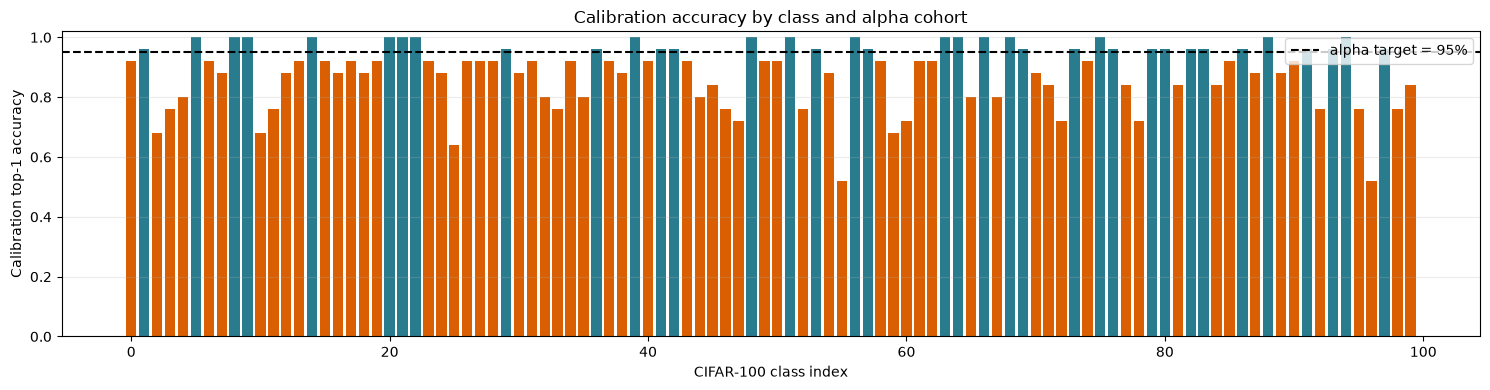

In [10]:
observed = class_performance["examples"] > 0
colors = np.where(
    class_performance.loc[observed, "alpha_cohort"] == "at_or_above_target",
    "#287c8e",
    "#d95f02",
)
fig, axis = plt.subplots(figsize=(15, 4))
axis.bar(class_performance.loc[observed, "class_id"], class_performance.loc[observed, "accuracy"], color=colors)
axis.axhline(TARGET_ALPHA, color="black", linestyle="--", label=f"alpha target = {TARGET_ALPHA:.0%}")
axis.set(
    title="Calibration accuracy by class and alpha cohort",
    xlabel="CIFAR-100 class index",
    ylabel="Calibration top-1 accuracy",
    ylim=(0, 1.02),
)
axis.grid(axis="y", alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

## Separate examples for analysis and future routing

Two assignments are useful and must not be confused:

- `target_alpha_cohort` groups examples by their known label and is valid only for retrospective labeled analysis.
- `predicted_alpha_cohort` groups examples by the model's predicted class and is available at inference time.

A future SDM comparison should report results for both cohorts, but any deployable routing or abstention rule must use only information available at inference time.

In [11]:
target_alpha_cohort = cohort[calibration_targets]
predicted_alpha_cohort = cohort[calibration_predictions]
is_correct = calibration_targets == calibration_predictions
softmax_confidence = calibration_arrays["probabilities"].max(axis=1)

cohort_rows = []
for assignment_name, assignments in {
    "target_class": target_alpha_cohort,
    "predicted_class": predicted_alpha_cohort,
}.items():
    for cohort_name in ("below_target", "at_or_above_target", "unobserved"):
        mask = assignments == cohort_name
        if not mask.any():
            continue
        cohort_rows.append({
            "assignment": assignment_name,
            "alpha_cohort": cohort_name,
            "examples": int(mask.sum()),
            "accuracy": float(is_correct[mask].mean()),
            "mean_softmax_confidence": float(softmax_confidence[mask].mean()),
        })

cohort_summary = pd.DataFrame(cohort_rows)
display(cohort_summary)

,assignment,alpha_cohort,examples,accuracy,mean_softmax_confidence
0,target_class,below_target,1600,0.833750,0.843349
1,target_class,at_or_above_target,900,0.980000,0.884636
2,predicted_class,below_target,1554,0.858430,0.848208
3,predicted_class,at_or_above_target,946,0.932347,0.874648


## Save the frozen development artifacts

The JSON class map is easy to inspect and version independently. The NumPy artifact adds both cohort assignments to the calibration outputs. All generated artifacts stay outside the repository.

In [12]:
cohort_table_path = RUN_DIR / f"alpha_class_cohorts_{suffix}.json"
cohort_outputs_path = RUN_DIR / f"calibration_alpha_cohorts_{suffix}.npz"
metadata_path = RUN_DIR / f"alpha_cohort_metadata_{suffix}.json"

cohort_records = json.loads(class_performance.to_json(orient="records"))
cohort_table_path.write_text(json.dumps(cohort_records, indent=2) + "\n", encoding="utf-8")
np.savez_compressed(
    cohort_outputs_path,
    **calibration_arrays,
    class_names=np.asarray(train_aug_base.classes),
    dataset_indices=calibration_indices[: len(calibration_targets)],
    target_alpha_cohort=target_alpha_cohort.astype(str),
    predicted_alpha_cohort=predicted_alpha_cohort.astype(str),
)

metadata = {
    "config": CONFIG,
    "split_sizes": {
        "training": len(train_dataset),
        "validation": len(validation_dataset),
        "calibration": len(calibration_dataset),
        "official_test_loaded": False,
    },
    "best_validation_accuracy": best_validation_accuracy,
    "reference_metrics": reference_metrics,
    "calibration_metrics": calibration_metrics,
    "cohort_class_counts": {key: int(value) for key, value in class_performance["alpha_cohort"].value_counts().items()},
    "cohort_summary": json.loads(cohort_summary.to_json(orient="records")),
    "complete_benchmark": not SMOKE,
    "versions": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "platform": platform.platform(),
    },
    "artifacts": {
        "checkpoint": str(checkpoint_path),
        "reference_outputs": str(reference_path),
        "calibration_outputs": str(calibration_path),
        "class_cohorts": str(cohort_table_path),
        "calibration_cohorts": str(cohort_outputs_path),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2) + "\n", encoding="utf-8")

print(f"Saved: {cohort_table_path}")
print(f"Saved: {cohort_outputs_path}")
print(f"Saved: {metadata_path}")

Saved: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/alpha_class_cohorts_full.json
Saved: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/calibration_alpha_cohorts_full.npz
Saved: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/alpha_cohort_metadata_full.json


## Reading the result and preparing the SDM comparison

- The classifier was trained with cross-entropy and evaluated here with ordinary softmax probabilities.
- The two alpha cohorts come only from the calibration split. They identify where the baseline appears weaker or stronger; they do not prove 95% reliability.
- Because each class has only 25 calibration examples, report class counts, intervals, and aggregate cohort coverage alongside point accuracy.
- The next notebook can use `reference_outputs_full.npz` to construct SDM similarity and distance signals, use calibration data to fit all SDM choices and thresholds, and compare frozen softmax and SDM methods.
- Load the official test set only after the SDM definition, hyperparameters, cohort map, and abstention rules are frozen. Evaluate both methods once on the same examples and report accuracy together with coverage.